# LLM Performance Metrics — All Scenarios

In [7]:

# =============================================================================
# LLM Performance Metrics — Extract & Compile from updated_MCP CSVs + chat.jsons
# =============================================================================

import json
import pandas as pd
from pathlib import Path

BASE = Path(".")

# ── per-scenario file map ──────────────────────────────────────────────────────
SCENARIOS = [
    ("GPT-5.1",     "Gpt_5",      "Scenario_1", "Gpt_5_Scenario_1_chat_summary.csv"),
    ("GPT-5.1",     "Gpt_5",      "Scenario_2", "Gpt_5_Scenario_2_chat_summary.csv"),
    ("GPT-5.1",     "Gpt_5",      "Scenario_3", "Gpt_5_Scenario_3_chat_summary.csv"),
    ("GPT-o4-mini", "Gpt_o4_mini","Scenario_1", "Gpt_o4_mini_Scenario_1_chat_summary.csv"),
    ("GPT-o4-mini", "Gpt_o4_mini","Scenario_2", "Gpt_o4_mini_Scenario_2_chat_summary.csv"),
    ("GPT-o4-mini", "Gpt_o4_mini","Scenario_3", "Gpt_o4_mini_Scenario_3_chat_summary.csv"),
    ("Sonnet-4",    "Sonnet_4",   "Scenario_1", "Sonnet_4_Scenario_1_chat_summary.csv"),
    ("Sonnet-4",    "Sonnet_4",   "Scenario_2", "Sonnet_4_Scenario_2_chat_summary.csv"),
    ("Sonnet-4",    "Sonnet_4",   "Scenario_3", "Sonnet_4_Scenario_3_chat_summary.csv"),
]

# ── helper: safe column lookup (handles mcp_ vs plain prefix variants) ─────────
def col(row, *names, default="N/A"):
    for n in names:
        if n in row.index and pd.notna(row[n]):
            return row[n]
    return default

# ── helper: classify intervention messages from chat.json ──────────────────────
def classify_interventions(chat_path: Path):
    """
    Returns a list of (type, snippet) tuples for each request AFTER the first.
    Types: 'max_tools_continue' | 'short_prompt' | 'confirmation'
    """
    if not chat_path.exists():
        return []
    with open(chat_path) as f:
        data = json.load(f)
    requests = data.get("requests", []) if isinstance(data, dict) else data
    results = []
    for req in requests[1:]:   # skip the initial user prompt (request 0)
        msg = req.get("message", {})
        parts = msg.get("parts", []) if isinstance(msg, dict) else []
        texts, is_agent = [], False
        for p in parts:
            if isinstance(p, dict):
                if "agent" in p:
                    is_agent = True
                if "text" in p:
                    texts.append(p["text"].strip())
        combined = " ".join(t for t in texts if t)
        lc = combined.lower().strip()
        if "try again" in lc:
            itype = "error_retry"
        elif "continue" in lc or is_agent:
            itype = "max_tools_continue"
        elif lc in ("yes", "yes please", "ok", "okay", "proceed", "go ahead"):
            itype = "confirmation"
        else:
            itype = "short_prompt"
        results.append((itype, combined[:80] if combined else "[button click]"))
    return results

# ── helper: count MCP tool calls from chat.json (incl. subagent-invoked) ───────
_QUERY_KW = ("list_", "get_", "check_", "analyze_", "status")
# Tools that repeat legitimately in iterative simulation workflows
# (build→run→check cycle); only flagged as retries when invoked via subagent
_ITER_SAFE_KW = ("set_default_session", "build_simulation", "run_simulation")
_RETRY_WINDOW = 3

def count_mcp_from_chat(chat_path: Path):
    """Parse chat.json to count ALL MCP tool invocations (including those
    executed inside subagents, which are missed by tool_metrics.csv) and
    detect genuine retries using two complementary signals:
      1. Window-based: same tool+input within the last few MCP calls
         (excludes query tools and iteration-safe simulation tools).
      2. Subagent-based: duplicate tool+input among subagent-invoked calls
         (agent delegates to a subagent to retry a failed operation)."""
    if not chat_path.exists():
        return 0, 0, 0          # total, in_subagent, retries
    with open(chat_path) as f:
        data = json.load(f)
    requests = data.get("requests", []) if isinstance(data, dict) else data

    total_mcp = 0
    in_subagent = 0
    window_retries = 0
    subagent_retries = 0

    for req in requests:
        resp = req.get("response", [])
        if not isinstance(resp, list):
            continue
        recent = []             # ordered (tool_id, input) for all MCP calls
        sub_seen = {}           # (tool_id, input) → count for subagent calls
        for item in resp:
            if not isinstance(item, dict):
                continue
            if item.get("kind") != "toolInvocationSerialized":
                continue
            source = item.get("source", {})
            if not (isinstance(source, dict) and source.get("type") == "mcp"):
                continue
            total_mcp += 1
            in_sub = "subAgentInvocationId" in item
            if in_sub:
                in_subagent += 1

            tool_id = item.get("toolId", "")
            rd = item.get("resultDetails", {})
            inp = rd.get("input", "") if isinstance(rd, dict) else ""
            tool_suffix = tool_id.split("mcp_")[-1] if "mcp_" in tool_id else tool_id
            is_query = any(kw in tool_suffix for kw in _QUERY_KW)
            is_iter_safe = any(kw in tool_suffix for kw in _ITER_SAFE_KW)

            # 1) window retries: exclude query + iteration-safe tools
            if not is_query and not is_iter_safe:
                window = recent[-_RETRY_WINDOW:]
                if any(t == tool_id and i == inp for t, i in window):
                    window_retries += 1

            # 2) subagent retries: same tool+input invoked via multiple subagents
            if in_sub:
                key = (tool_id, inp)
                sub_seen[key] = sub_seen.get(key, 0) + 1

            recent.append((tool_id, inp))

        for _key, count in sub_seen.items():
            if count > 1:
                subagent_retries += count - 1

    total_retries = window_retries + subagent_retries
    return total_mcp, in_subagent, total_retries

# ── build the metrics table ────────────────────────────────────────────────────
records = []

for llm, folder, scenario, summary_csv in SCENARIOS:
    folder_path  = BASE / folder / scenario
    summary_path = folder_path / summary_csv

    if not summary_path.exists():
        print(f"[WARN] Not found: {summary_path}")
        continue

    df  = pd.read_csv(summary_path)
    row = df.iloc[0]

    # total retries from tool_metrics (sum of retry_count column)
    tm_files = list(folder_path.glob("*tool_metrics.csv"))
    total_retries = 0
    if tm_files:
        tm = pd.read_csv(tm_files[0])
        if "retry_count" in tm.columns:
            total_retries = int(tm["retry_count"].sum())

    interventions = classify_interventions(folder_path / "chat.json")

    n_cont   = sum(1 for t, _ in interventions if t == "max_tools_continue")
    n_conf   = sum(1 for t, _ in interventions if t == "confirmation")
    n_short  = sum(1 for t, _ in interventions if t == "short_prompt")
    n_err    = sum(1 for t, _ in interventions if t == "error_retry")

    parts_desc = []
    if n_err:   parts_desc.append(f"{n_err}x error retry")
    if n_cont:  parts_desc.append(f"{n_cont}x continue (max-tools)")
    if n_conf:  parts_desc.append(f"{n_conf}x confirmation")
    if n_short: parts_desc.append(f"{n_short}x short prompt")
    intervention_desc = "; ".join(parts_desc) if parts_desc else "—"

    wall_min   = round(float(col(row, "total_wall_time_s", default=0)) / 60, 1)
    prompt_tok = int(col(row, "total_prompt_tokens",     default=0))
    compl_tok  = int(col(row, "total_completion_tokens", default=0))
    total_tok  = int(col(row, "total_tokens",            default=0))
    tokens_str    = f"{total_tok:,}"                    if total_tok > 0 else "N/A"
    tokens_detail = f"{prompt_tok:,} / {compl_tok:,}"  if total_tok > 0 else "N/A"

    mcp_total   = int(col(row, "total_mcp_tool_calls", "total_tool_calls",   default=0))
    mcp_success = int(col(row, "total_mcp_tool_calls_success", "total_tool_calls_success", default=0))
    mcp_failed  = int(col(row, "total_mcp_tool_calls_failed",  "total_tool_calls_failed",  default=0))
    mcp_rate    = col(row, "mcp_tool_success_rate_pct", "tool_success_rate_pct", default="N/A")
    mcp_retries = max(total_retries,
                      int(col(row, "total_mcp_retries", "total_retries", default=0)))
    n_max_tools = int(col(row, "n_max_tools_exceeded", default=0))

    # ── correct MCP counts using chat.json (catches subagent-invoked calls
    #    and semantic retries missed by tool_metrics.csv) ───────────────────
    chat_mcp_total, chat_sub, chat_retries = count_mcp_from_chat(
        folder_path / "chat.json"
    )
    if chat_mcp_total > mcp_total:
        extra = chat_mcp_total - mcp_total
        mcp_success += extra          # subagent MCP calls all succeeded
        mcp_total    = chat_mcp_total
        if mcp_total > 0:
            mcp_rate = round(mcp_success / mcp_total * 100, 1)
    mcp_retries = max(mcp_retries, chat_retries)

    records.append({
        "LLM":                     llm,
        "Scenario":                scenario.replace("_", " "),
        "Wall Time (min)":         wall_min,
        "Prompt / Completion Tok": tokens_detail,
        "Total Tokens":            tokens_str,
        "User Interventions":      len(interventions),
        "Intervention Kind":       intervention_desc,
        "MCP Tool Calls":          mcp_total,
        "MCP Successes":           mcp_success,
        "MCP Failures":            mcp_failed,
        "Tool Success Rate (%)":   mcp_rate,
        "MCP Retries":             mcp_retries,
        "Max-Tools Events":        n_max_tools,
        "Outcome":                 "Success",
    })

metrics_df = pd.DataFrame(records)

print(metrics_df.to_string(index=False))


        LLM   Scenario  Wall Time (min) Prompt / Completion Tok Total Tokens  User Interventions                        Intervention Kind  MCP Tool Calls  MCP Successes  MCP Failures  Tool Success Rate (%)  MCP Retries  Max-Tools Events Outcome
    GPT-5.1 Scenario 1              7.0         119,701 / 3,343      123,044                   3         2x confirmation; 1x short prompt              34             34             0                  100.0            0                 0 Success
    GPT-5.1 Scenario 2              2.9          45,097 / 1,571       46,668                   0                                        —              23             23             0                  100.0            0                 0 Success
    GPT-5.1 Scenario 3             70.6         107,875 / 2,723      110,598                   1                  1x continue (max-tools)              52             52             0                  100.0            0                 1 Success
GPT-o4-mini Scenario

In [8]:

# =============================================================================
# User intervention detail — full message text per request
# =============================================================================
import json
import textwrap
import matplotlib.pyplot as plt
from IPython.display import display

detail_rows = []
TYPE_LABEL = {
    "error_retry":        "Error retry",
    "max_tools_continue": "Max-tools continue",
    "confirmation":       "Confirmation",
    "short_prompt":       "Short prompt",
}

for llm, folder, scenario, _ in SCENARIOS:
    chat_path = BASE / folder / scenario / "chat.json"
    if not chat_path.exists():
        continue
    with open(chat_path) as f:
        data = json.load(f)
    requests = data.get("requests", []) if isinstance(data, dict) else data

    for req_idx, req in enumerate(requests):
        msg   = req.get("message", {})
        parts = msg.get("parts", []) if isinstance(msg, dict) else []
        texts, is_agent = [], False
        for p in parts:
            if isinstance(p, dict):
                if "agent" in p:
                    is_agent = True
                if "text" in p:
                    texts.append(p["text"].strip())
        combined = " ".join(t for t in texts if t)
        lc = combined.lower().strip()

        if req_idx == 0:
            itype = "initial_prompt"
        elif "try again" in lc:
            itype = "error_retry"
        elif "continue" in lc or is_agent:
            itype = "max_tools_continue"
        elif lc in ("yes", "yes please", "ok", "okay", "proceed", "go ahead"):
            itype = "confirmation"
        else:
            itype = "short_prompt"

        detail_rows.append({
            "LLM":      llm,
            "Scenario": scenario.replace("_", " "),
            "Req #":    req_idx + 1,
            "Type":     TYPE_LABEL.get(itype, itype.replace("_", " ").title()),
            "Message":  combined if combined else "[button click - no text]",
        })

detail_df = (pd.DataFrame(detail_rows)
               .query("Type != 'Initial Prompt'")
               .reset_index(drop=True))

# ── styled HTML ───────────────────────────────────────────────────────────────
TYPE_COLORS = {
    "Error retry":        "#f8d7da",
    "Max-tools continue": "#fff3cd",
    "Confirmation":       "#d4edda",
    "Short prompt":       "#cce5ff",
}

def color_type(val):
    bg = TYPE_COLORS.get(val, "white")
    return "background-color: " + bg + ";"

styled = (detail_df.style
    .map(color_type, subset=["Type"])
    .set_caption("User Interventions — Full Message Text (excluding initial prompt)")
    .set_table_styles([
        {"selector": "th", "props": [("background", "#2C7BB6"), ("color", "white"),
                                     ("font-weight", "bold"), ("font-size", "16px"),
                                     ("padding", "10px 14px")]},
        {"selector": "td", "props": [("padding", "10px 14px"), ("font-size", "15px"),
                                     ("vertical-align", "top")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "18px"),
                                          ("font-weight", "bold"), ("padding", "10px 0")]},
        {"selector": "td:last-child", "props": [("max-width", "780px"),
                                                 ("white-space", "pre-wrap"),
                                                 ("word-break", "break-word")]},
    ])
    .hide(axis="index")
)
display(styled)

# ── save to CSV ───────────────────────────────────────────────────────────────
detail_df.to_csv("outputs/metrics/llm_interventions_detail.csv", index=False)
print("Saved: outputs/metrics/llm_interventions_detail.csv")

# ── save table as readable PNG/PDF ────────────────────────────────────────────
_TYPE_BG = {
    "Error retry":        (0.973, 0.843, 0.855),
    "Max-tools continue": (1.000, 0.953, 0.804),
    "Confirmation":       (0.831, 0.929, 0.831),
    "Short prompt":       (0.800, 0.898, 1.000),
}

def wrap_detail_table(df, wrap_width=44):
    plot_df = df.copy()
    plot_df["Message"] = plot_df["Message"].map(
        lambda msg: textwrap.fill(str(msg), width=wrap_width, break_long_words=False, break_on_hyphens=False)
    )
    return plot_df


def save_detail_table(df, title, png_path, pdf_path, body_font=18, header_font=20, title_font=24):
    plot_df = wrap_detail_table(df)
    row_line_counts = [max(1, msg.count("\n") + 1) for msg in plot_df["Message"]]
    row_units = [1.35 + 1.00 * (n_lines - 1) for n_lines in row_line_counts]
    header_units = 2.0
    total_units = header_units + sum(row_units)
    fig_h = max(10.0, 1.05 * sum(row_units) + 2.8)

    fig, ax = plt.subplots(figsize=(22, fig_h))
    ax.axis("off")
    tbl = ax.table(
        cellText=plot_df.values,
        colLabels=plot_df.columns,
        cellLoc="left",
        colLoc="left",
        colWidths=[0.12, 0.12, 0.08, 0.16, 0.52],
        loc="upper left",
        bbox=[0.01, 0, 0.98, 1],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(body_font)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_linewidth(0.7)
        cell.PAD = 0.02
        if row == 0:
            cell.set_height(header_units / total_units)
            cell.set_facecolor("#2C7BB6")
            cell.set_text_props(color="white", fontweight="bold", fontsize=header_font, va="center")
        else:
            cell.set_height(row_units[row - 1] / total_units)
            type_val = df.iloc[row - 1]["Type"]
            if col == 3:
                cell.set_facecolor(_TYPE_BG.get(type_val, (1, 1, 1)))
            elif row % 2 == 0:
                cell.set_facecolor((0.96, 0.96, 0.96))
            else:
                cell.set_facecolor((1.0, 1.0, 1.0))
            if col == 2:
                cell.set_text_props(ha="center", va="center", fontsize=body_font)
            else:
                cell.set_text_props(ha="left", va="center", fontsize=body_font)

    fig.suptitle(title, fontsize=title_font, fontweight="bold", y=1.01)
    plt.tight_layout(pad=0.9)
    plt.savefig(png_path, dpi=500, bbox_inches="tight", pad_inches=0.18)
    plt.savefig(pdf_path, bbox_inches="tight", pad_inches=0.18)
    plt.close()
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")

save_detail_table(
    detail_df,
    "User Interventions — Full Message Text (excluding initial prompt)",
    "outputs/figures/llm_interventions_detail.png",
    "outputs/figures/llm_interventions_detail.pdf",
)

for llm_name, llm_df in detail_df.groupby("LLM", sort=False):
    slug = llm_name.lower().replace("-", "_").replace(".", "_")
    save_detail_table(
        llm_df.reset_index(drop=True),
        f"User Interventions — {llm_name}",
        f"outputs/figures/llm_interventions_detail_{slug}.png",
        f"outputs/figures/llm_interventions_detail_{slug}.pdf",
        body_font=19,
        header_font=21,
        title_font=25,
    )


LLM,Scenario,Req #,Type,Message
GPT-5.1,Scenario 1,2,Confirmation,yes please
GPT-5.1,Scenario 1,3,Confirmation,yes please
GPT-5.1,Scenario 1,4,Short prompt,Tune TNF resources
GPT-5.1,Scenario 3,2,Max-tools continue,"Continue: ""Continue to iterate?"""
GPT-o4-mini,Scenario 1,2,Short prompt,Proceed to the next phase.
GPT-o4-mini,Scenario 1,3,Short prompt,Export the physicell configuration
GPT-o4-mini,Scenario 3,2,Error retry,Try Again
Sonnet-4,Scenario 1,2,Max-tools continue,"Continue: ""Continue to iterate?"""
Sonnet-4,Scenario 1,3,Confirmation,yes please
Sonnet-4,Scenario 1,4,Max-tools continue,"Continue: ""Continue to iterate?"""


Saved: outputs/metrics/llm_interventions_detail.csv
Saved: outputs/figures/llm_interventions_detail.png
Saved: outputs/figures/llm_interventions_detail.pdf
Saved: outputs/figures/llm_interventions_detail_gpt_5_1.png
Saved: outputs/figures/llm_interventions_detail_gpt_5_1.pdf
Saved: outputs/figures/llm_interventions_detail_gpt_o4_mini.png
Saved: outputs/figures/llm_interventions_detail_gpt_o4_mini.pdf
Saved: outputs/figures/llm_interventions_detail_sonnet_4.png
Saved: outputs/figures/llm_interventions_detail_sonnet_4.pdf


LLM,Scenario,Wall Time (min),Prompt / Completion Tok,Total Tokens,User Interventions,Intervention Kind,MCP Tool Calls,MCP Successes,MCP Failures,Tool Success Rate (%),MCP Retries,Max-Tools Events,Outcome
GPT-5.1,Scenario 1,7.000000,"119,701 / 3,343","123,044",3,2x confirmation; 1x short prompt,34,34,0,100.000000,0,0,Success
GPT-5.1,Scenario 2,2.900000,"45,097 / 1,571","46,668",0,—,23,23,0,100.000000,0,0,Success
GPT-5.1,Scenario 3,70.600000,"107,875 / 2,723","110,598",1,1x continue (max-tools),52,52,0,100.000000,0,1,Success
GPT-o4-mini,Scenario 1,3.000000,N/A,N/A,2,2x short prompt,23,23,0,100.000000,0,0,Success
GPT-o4-mini,Scenario 2,1.200000,N/A,N/A,0,—,13,13,0,100.000000,0,0,Success
GPT-o4-mini,Scenario 3,9.600000,N/A,N/A,1,1x error retry,17,17,0,100.000000,3,0,Success
Sonnet-4,Scenario 1,12.600000,"199,096 / 2,448","201,544",3,2x continue (max-tools); 1x confirmation,37,37,0,100.000000,0,2,Success
Sonnet-4,Scenario 2,2.800000,"108,966 / 905","109,871",1,1x continue (max-tools),25,25,0,100.000000,0,1,Success
Sonnet-4,Scenario 3,40.000000,"130,761 / 1,199","131,960",1,1x continue (max-tools),56,56,0,100.000000,0,1,Success


Saved: outputs/metrics/llm_performance_metrics.csv
Saved: outputs/figures/llm_performance_metrics_overview.png
Saved: outputs/figures/llm_performance_metrics_overview.pdf
Saved: outputs/figures/llm_performance_metrics_tools.png
Saved: outputs/figures/llm_performance_metrics_tools.pdf
Saved: outputs/figures/llm_performance_metrics.png
Saved: outputs/figures/llm_performance_metrics.pdf
Saved: outputs/tables/llm_performance_metrics.tex


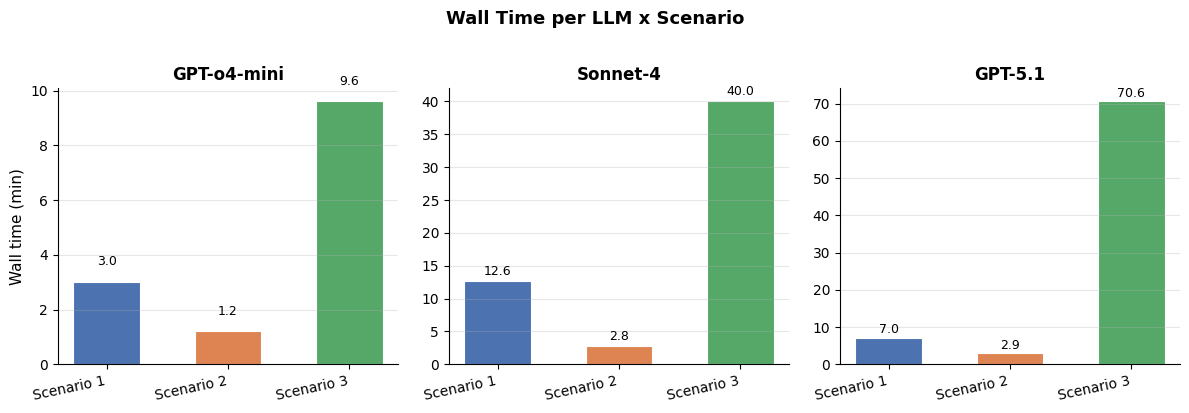

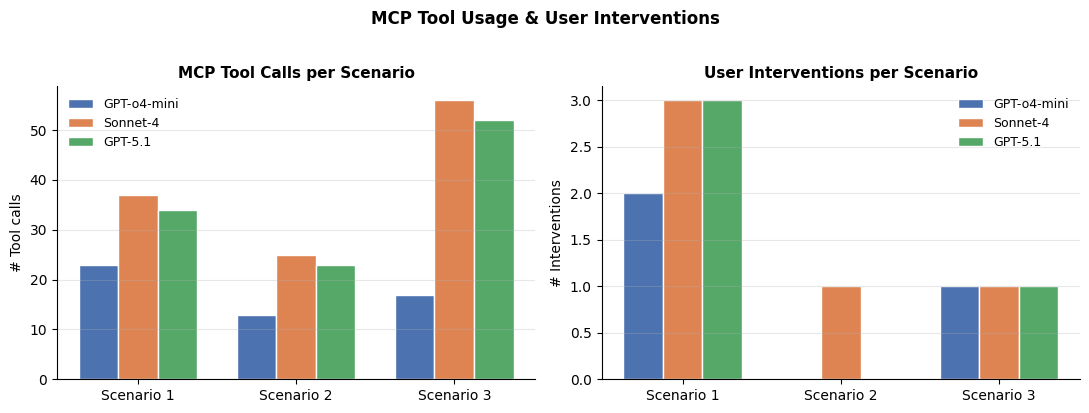

Saved: outputs/figures/llm_wall_time_comparison.pdf/.png and outputs/figures/llm_tool_interventions_comparison.pdf/.png


In [10]:

# =============================================================================
# Display styled table + export to CSV, PNG, LaTeX + bar charts
# =============================================================================

import textwrap
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np

# ── 1. Styled HTML table display ─────────────────────────────────────────────
display(metrics_df.style
    .set_caption("LLM Performance Metrics — All Scenarios")
    .set_table_styles([
        {"selector": "th", "props": [("background", "#2C7BB6"), ("color", "white"),
                                      ("font-weight", "bold"), ("font-size", "16px"),
                                      ("padding", "10px 14px"), ("text-align", "center")]},
        {"selector": "td", "props": [("padding", "10px 14px"), ("font-size", "15px"),
                                      ("text-align", "center")]},
        {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "18px"),
                                           ("font-weight", "bold"), ("padding", "10px 0")]},
    ])
    .set_properties(**{"border": "1px solid #ddd"})
    .hide(axis="index")
)

# ── 2. CSV export ─────────────────────────────────────────────────────────────
csv_out = "outputs/metrics/llm_performance_metrics.csv"
metrics_df.to_csv(csv_out, index=False)
print(f"Saved: {csv_out}")

# ── 3. PNG/PDF export of the metrics table ────────────────────────────────────
overview_cols = [
    "LLM", "Scenario", "Wall Time (min)", "Total Tokens",
    "Prompt / Completion Tok", "Outcome",
]
overview_df = metrics_df[overview_cols].copy().rename(columns={
    "Wall Time (min)": "Wall Time\n(min)",
    "Total Tokens": "Total\nTokens",
    "Prompt / Completion Tok": "Prompt / Completion\nTokens",
})

tools_cols = [
    "LLM", "Scenario", "User Interventions", "Intervention Kind",
    "MCP Tool Calls", "Tool Success Rate (%)", "MCP Retries", "Max-Tools Events",
]
tools_df = metrics_df[tools_cols].copy().rename(columns={
    "User Interventions": "User\nInterventions",
    "Intervention Kind": "Intervention\nKind",
    "MCP Tool Calls": "MCP Tool\nCalls",
    "Tool Success Rate (%)": "Tool Success\nRate (%)",
    "MCP Retries": "MCP\nRetries",
    "Max-Tools Events": "Max-Tools\nEvents",
})
tools_df["Intervention\nKind"] = tools_df["Intervention\nKind"].map(
    lambda msg: textwrap.fill(str(msg), width=24, break_long_words=False, break_on_hyphens=False)
)

_llm_clr = {"GPT-o4-mini": (0.878, 0.918, 1.000),
            "Sonnet-4":    (1.000, 0.937, 0.851),
            "GPT-5.1":     (0.847, 0.973, 0.878)}


def draw_table(ax, df, title, col_widths, body_font=18, header_font=20, title_font=24):
    ax.axis("off")
    row_units = []
    for _, row in df.iterrows():
        max_lines = max(str(value).count("\n") + 1 for value in row)
        row_units.append(1.35 + 0.80 * (max_lines - 1))
    header_units = 2.0
    total_units = header_units + sum(row_units)

    tbl = ax.table(
        cellText=df.values,
        colLabels=df.columns,
        cellLoc="center",
        colLoc="center",
        colWidths=col_widths,
        loc="upper left",
        bbox=[0.01, 0, 0.98, 1],
    )
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(body_font)

    for (row, col), cell in tbl.get_celld().items():
        cell.set_linewidth(0.7)
        cell.PAD = 0.02
        if row == 0:
            cell.set_height(header_units / total_units)
            cell.set_facecolor("#2C7BB6")
            cell.set_text_props(color="white", fontweight="bold", fontsize=header_font, va="center")
        else:
            cell.set_height(row_units[row - 1] / total_units)
            llm_val = df.iloc[row - 1]["LLM"]
            cell.set_facecolor(_llm_clr.get(llm_val, (1, 1, 1)))
            if df.columns[col] in ("Intervention\nKind", "Intervention Kind"):
                cell.set_text_props(ha="left", va="center", fontsize=body_font)
            else:
                cell.set_text_props(ha="center", va="center", fontsize=body_font)

    ax.set_title(title, fontsize=title_font, fontweight="bold", pad=14)
    return sum(row_units)


def save_single_table_figure(df, title, png_path, pdf_path, col_widths, fig_width, body_font=18, header_font=20):
    row_units = []
    for _, row in df.iterrows():
        max_lines = max(str(value).count("\n") + 1 for value in row)
        row_units.append(1.35 + 0.80 * (max_lines - 1))
    fig_h = max(7.5, 1.15 * sum(row_units) + 2.5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_h))
    draw_table(ax, df, title, col_widths, body_font=body_font, header_font=header_font, title_font=23)
    plt.tight_layout(pad=0.9)
    plt.savefig(png_path, dpi=500, bbox_inches="tight", pad_inches=0.18)
    plt.savefig(pdf_path, bbox_inches="tight", pad_inches=0.18)
    plt.close()
    print(f"Saved: {png_path}")
    print(f"Saved: {pdf_path}")

save_single_table_figure(
    overview_df,
    "Benchmark Summary",
    "outputs/figures/llm_performance_metrics_overview.png",
    "outputs/figures/llm_performance_metrics_overview.pdf",
    [0.15, 0.14, 0.13, 0.14, 0.30, 0.14],
    fig_width=19,
    body_font=19,
    header_font=21,
)
save_single_table_figure(
    tools_df,
    "User Interventions and Tool-Call Diagnostics",
    "outputs/figures/llm_performance_metrics_tools.png",
    "outputs/figures/llm_performance_metrics_tools.pdf",
    [0.12, 0.10, 0.13, 0.19, 0.11, 0.13, 0.10, 0.12],
    fig_width=20,
    body_font=18,
    header_font=20,
)

overview_row_units = [1.35] * len(overview_df)
tools_row_units = []
for _, row in tools_df.iterrows():
    max_lines = max(str(value).count("\n") + 1 for value in row)
    tools_row_units.append(1.35 + 0.80 * (max_lines - 1))

height_ratios = [sum(overview_row_units) + 2.4, sum(tools_row_units) + 3.0]
fig_m, (ax_top, ax_bottom) = plt.subplots(
    2,
    1,
    figsize=(20, 22),
    gridspec_kw={"height_ratios": height_ratios},
)

draw_table(
    ax_top,
    overview_df,
    "Benchmark Summary",
    [0.15, 0.14, 0.13, 0.14, 0.30, 0.14],
    body_font=19,
    header_font=21,
    title_font=23,
)
draw_table(
    ax_bottom,
    tools_df,
    "User Interventions and Tool-Call Diagnostics",
    [0.12, 0.10, 0.13, 0.19, 0.11, 0.13, 0.10, 0.12],
    body_font=18,
    header_font=20,
    title_font=23,
)

fig_m.suptitle(
    "LLM Performance Metrics — All Scenarios",
    fontsize=25,
    fontweight="bold",
    y=0.995,
)
plt.tight_layout(rect=[0, 0, 1, 0.985], h_pad=2.4)
plt.savefig("outputs/figures/llm_performance_metrics.png", dpi=500, bbox_inches="tight", pad_inches=0.18)
plt.savefig("outputs/figures/llm_performance_metrics.pdf", bbox_inches="tight", pad_inches=0.18)
plt.close()
print("Saved: outputs/figures/llm_performance_metrics.png")
print("Saved: outputs/figures/llm_performance_metrics.pdf")

# ── 4. LaTeX export ───────────────────────────────────────────────────────────
def tex(s):
    return (str(s)
            .replace("\\", "\\textbackslash ")
            .replace("_",  "\\_")
            .replace("%",  "\\%")
            .replace("&",  "\\&")
            .replace("#",  "\\#"))

# columns to include in LaTeX: (df_col, align, latex_header)
cols_tex = [
    ("LLM",                    "l", "LLM"),
    ("Scenario",               "l", "Scenario"),
    ("Wall Time (min)",        "r", "Wall time (min)"),
    ("Total Tokens",           "r", "Total tokens"),
    ("Prompt / Completion Tok","r", "Prompt / compl.\\ tokens"),
    ("User Interventions",     "r", "Interventions"),
    ("Intervention Kind",      "l", "Intervention kind"),
    ("MCP Tool Calls",         "r", "MCP calls"),
    ("Tool Success Rate (%)","r",   "Success rate (\\%)"),
    ("MCP Retries",            "r", "Retries"),
    ("Max-Tools Events",       "r", "Max-tools"),
    ("Outcome",                "c", "Outcome"),
]

col_fmt  = "".join(c[1] for c in cols_tex)
col_hdrs = " & ".join(c[2] for c in cols_tex)

lines = [
    r"\begin{table*}[htbp]",
    r"\centering",
    (r"\caption{LLM performance metrics across all scenarios. "
     r"Wall time is accumulated server-side processing time. "
     r"Tokens are billed input/output tokens (N/A for GPT-o4-mini: not exported by the client). "
     r"Intervention kinds: \textit{continue (max-tools)} = VS~Code max-tool-limit button click; "
     r"\textit{confirmation} = short affirmative reply; \textit{short prompt} = brief user instruction.}"),
    r"\label{tab:llm_performance_metrics}",
    r"\small",
    r"\begin{tabular}{" + col_fmt + "}",
    r"\toprule",
    col_hdrs + r" \\",
    r"\midrule",
]

prev_llm = None
for _, row in metrics_df.iterrows():
    if row["LLM"] != prev_llm:
        if prev_llm is not None:
            lines.append(r"\midrule")
        prev_llm = row["LLM"]
    cells = " & ".join(tex(row[c[0]]) for c in cols_tex)
    lines.append(cells + r" \\")

lines += [r"\bottomrule", r"\end{tabular}", r"\end{table*}"]

latex_out = "outputs/tables/llm_performance_metrics.tex"
from pathlib import Path
Path(latex_out).write_text("\n".join(lines))
print(f"Saved: {latex_out}")

# ── 5. Bar chart: Wall time ───────────────────────────────────────────────────
llms      = ["GPT-o4-mini", "Sonnet-4", "GPT-5.1"]
scenarios = ["Scenario 1", "Scenario 2", "Scenario 3"]
colors    = ["#4C72B0", "#DD8452", "#55A868"]
x         = np.arange(len(scenarios))
width     = 0.55

fig, axes = plt.subplots(1, 3, figsize=(12, 4), sharey=False)
for ax, llm in zip(axes, llms):
    sub  = metrics_df[metrics_df["LLM"] == llm].set_index("Scenario")
    vals = [sub.loc[s, "Wall Time (min)"] if s in sub.index else 0 for s in scenarios]
    bars = ax.bar(x, vals, width, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(llm, fontsize=12, fontweight="bold")
    ax.set_xticks(x)
    ax.set_xticklabels(scenarios, rotation=12, ha="right", fontsize=10)
    ax.set_ylabel("Wall time (min)" if ax is axes[0] else "", fontsize=11)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f"{v:.1f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Wall Time per LLM x Scenario", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/figures/llm_wall_time_comparison.pdf", dpi=300, bbox_inches="tight")
plt.savefig("outputs/figures/llm_wall_time_comparison.png", dpi=300, bbox_inches="tight")
plt.show()

# ── 6. Bar chart: MCP tool calls & User interventions ────────────────────────
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

llm_colors = {"GPT-o4-mini": "#4C72B0", "Sonnet-4": "#DD8452", "GPT-5.1": "#55A868"}
x2    = np.arange(len(scenarios))
w2    = 0.25

for col_key, ax, title, ylabel in [
    ("MCP Tool Calls",     ax1, "MCP Tool Calls per Scenario",       "# Tool calls"),
    ("User Interventions", ax2, "User Interventions per Scenario",   "# Interventions"),
]:
    for i, llm in enumerate(["GPT-o4-mini", "Sonnet-4", "GPT-5.1"]):
        sub  = metrics_df[metrics_df["LLM"] == llm].set_index("Scenario")
        vals = [sub.loc[s, col_key] if s in sub.index else 0 for s in scenarios]
        offset = (i - 1) * w2
        ax.bar(x2 + offset, vals, w2, label=llm, color=llm_colors[llm], edgecolor="white")
    ax.set_title(title, fontsize=11, fontweight="bold")
    ax.set_xticks(x2)
    ax.set_xticklabels(scenarios, fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.legend(fontsize=9, frameon=False)
    ax.grid(axis="y", alpha=0.3)
    ax.spines[["top", "right"]].set_visible(False)

fig2.suptitle("MCP Tool Usage & User Interventions", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("outputs/figures/llm_tool_interventions_comparison.pdf", dpi=300, bbox_inches="tight")
plt.savefig("outputs/figures/llm_tool_interventions_comparison.png", dpi=300, bbox_inches="tight")
plt.show()
print("Saved: outputs/figures/llm_wall_time_comparison.pdf/.png and outputs/figures/llm_tool_interventions_comparison.pdf/.png")
